# 1. Import Libraries

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder

import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

from lightgbm import LGBMClassifier
import lightgbm as lgb
from scipy.stats import uniform, randint
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


# 2. Import Train, Test

In [88]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [89]:
#Droping "id" column
train = train.drop("id", axis=1)
test = test.drop("id", axis=1)

# 3. EDA

In [90]:
print(f"df Train shape {train.shape}")
print(f"df Test shape {test.shape}")

df Train shape (593994, 12)
df Test shape (254569, 11)


In [91]:
def data_info(df, df_name):
    """Comprehensive overview of a DataFrame with styled output."""

    print(f"\n{'='*80}")
    print(f"📊 Comprehensive Information for DataFrame: {df_name}")
    print(f"{'='*80}\n")

    # --- Shape ---
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

    # --- Head ---
    print(f"--- {df_name} Head ---\n")
    display(df.head().style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', 'lightblue'), ('color', 'black')]},
        {'selector': 'td', 'props': [('font-size', '10pt')]}
    ], overwrite=False))

    # --- Column Summary ---
    print(f"\n--- {df_name} Column Summary ---\n")
    summary = pd.DataFrame({
        "DataType": df.dtypes,
        "Non-Null Count": df.notnull().sum(),
        "Unique Values": df.nunique(),
        "Missing Values": df.isnull().sum(),
        "Missing %": (df.isnull().sum() / len(df)) * 100
    })
    display(summary.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', 'lightblue'), ('color', 'black')]},
        {'selector': 'td', 'props': [('font-size', '10pt')]}
    ], overwrite=False))

    # --- Describe (numeric only) ---
    if df.select_dtypes(include=np.number).shape[1] > 0:
        print(f"\n--- {df_name} Numeric Summary ---\n")
        display(df.describe().style.set_table_styles([
            {'selector': 'th', 'props': [('background-color', 'lightblue'), ('color', 'black')]},
            {'selector': 'td', 'props': [('font-size', '10pt')]}
        ], overwrite=False))

    # --- Describe (categorical only) ---
    cat_cols = df.select_dtypes(exclude=np.number).columns
    if len(cat_cols) > 0:
        print(f"\n--- {df_name} Categorical Summary ---\n")
        cat_summary = df[cat_cols].describe().transpose()
        display(cat_summary.style.set_table_styles([
            {'selector': 'th', 'props': [('background-color', 'lightblue'), ('color', 'black')]},
            {'selector': 'td', 'props': [('font-size', '10pt')]}
        ], overwrite=False))

    print(f"\n{'='*80}\n")

# Apply
data_info(train, "train")
data_info(test, "test")


📊 Comprehensive Information for DataFrame: train

Shape: 593994 rows × 12 columns

--- train Head ---



,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.990000,0.084000,736,2528.420000,13.670000,Female,Single,High School,Self-employed,Other,C3,1.000000
1,22108.020000,0.166000,636,4593.100000,12.920000,Male,Married,Master's,Employed,Debt consolidation,D3,0.000000
2,49566.200000,0.097000,694,17005.150000,9.760000,Male,Single,High School,Employed,Debt consolidation,C5,1.000000
3,46858.250000,0.065000,533,4682.480000,16.100000,Female,Single,High School,Employed,Debt consolidation,F1,1.000000
4,25496.700000,0.053000,665,12184.430000,10.210000,Male,Married,High School,Employed,Other,D1,1.000000



--- train Column Summary ---



,DataType,Non-Null Count,Unique Values,Missing Values,Missing %
annual_income,float64,593994,119728,0,0.000000
debt_to_income_ratio,float64,593994,526,0,0.000000
credit_score,int64,593994,399,0,0.000000
loan_amount,float64,593994,111570,0,0.000000
interest_rate,float64,593994,1454,0,0.000000
gender,str,593994,3,0,0.000000
marital_status,str,593994,4,0,0.000000
education_level,str,593994,5,0,0.000000
employment_status,str,593994,5,0,0.000000
loan_purpose,str,593994,8,0,0.000000



--- train Numeric Summary ---



...

,DataType,Non-Null Count,Unique Values,Missing Values,Missing %
annual_income,float64,254569,67287,0,0.000000
debt_to_income_ratio,float64,254569,506,0,0.000000
credit_score,int64,254569,389,0,0.000000
loan_amount,float64,254569,65199,0,0.000000
interest_rate,float64,254569,1385,0,0.000000
gender,str,254569,3,0,0.000000
marital_status,str,254569,4,0,0.000000
education_level,str,254569,5,0,0.000000
employment_status,str,254569,5,0,0.000000
loan_purpose,str,254569,8,0,0.000000



--- test Numeric Summary ---



,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000
mean,48233.080193,0.120583,681.037691,15016.753484,12.352323
std,26719.658580,0.068582,55.624118,6922.165182,2.017602
min,6011.770000,0.011000,395.000000,500.050000,3.200000
25%,27950.300000,0.072000,646.000000,10248.580000,10.980000
50%,46528.980000,0.096000,683.000000,15000.220000,12.370000
75%,61149.440000,0.156000,719.000000,18831.460000,13.690000
max,380653.940000,0.627000,849.000000,48959.260000,21.290000



--- test Categorical Summary ---



,count,unique,top,freq
gender,254569,3,Female,131480
marital_status,254569,4,Single,123686
education_level,254569,5,Bachelor's,119924
employment_status,254569,5,Employed,193207
loan_purpose,254569,8,Debt consolidation,138963
grade_subgrade,254569,30,C3,25410


In [92]:

train.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


## Check Null and Duplicate Values

In [93]:
print("Number of null value in Train DF : ",train.isna().sum().sum())
print("Number of null value in Test DF : ",test.isna().sum().sum())

Number of null value in Train DF :  0
Number of null value in Test DF :  0


In [94]:
#Check Duplicate Rows
print("Number of Duplicated Row in Train DF : ", train.duplicated().sum())

Number of Duplicated Row in Train DF :  0


## Numerical and Categorical Features and Label

In [95]:
# Define excluded features: 'id' and the target variable 'loan_paid_back'
excluded_features = ['id', 'loan_paid_back']

print("\n--- Feature Classification Based on df_train ---")

# Separate numerical features from df_train, excluding the specified features
numerical_features = [
    col for col in train.select_dtypes(include=np.number).columns
    if col not in excluded_features
]

# Separate categorical features from df_train, excluding the specified features
categorical_features = [
    col for col in train.select_dtypes(exclude=np.number).columns
    if col not in excluded_features
]

print("Numerical Features:")
print(f"  Total Count: {len(numerical_features)}")
print(f"  List: {numerical_features}\n")

print("Categorical Features:")
print(f"  Total Count: {len(categorical_features)}")
print(f"  List: {categorical_features}\n")

print("Excluded Features (ID and Target Variable):")
print(f"  List: {excluded_features}\n")


--- Feature Classification Based on df_train ---
Numerical Features:
  Total Count: 5
  List: ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

Categorical Features:
  Total Count: 6
  List: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

Excluded Features (ID and Target Variable):
  List: ['id', 'loan_paid_back']



## Numerical Features Aalysis


In [96]:
train[numerical_features].describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345
std,26711.942078,0.068573,55.424956,6926.530568,2.008959
min,6002.430000,0.011000,395.000000,500.090000,3.200000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000


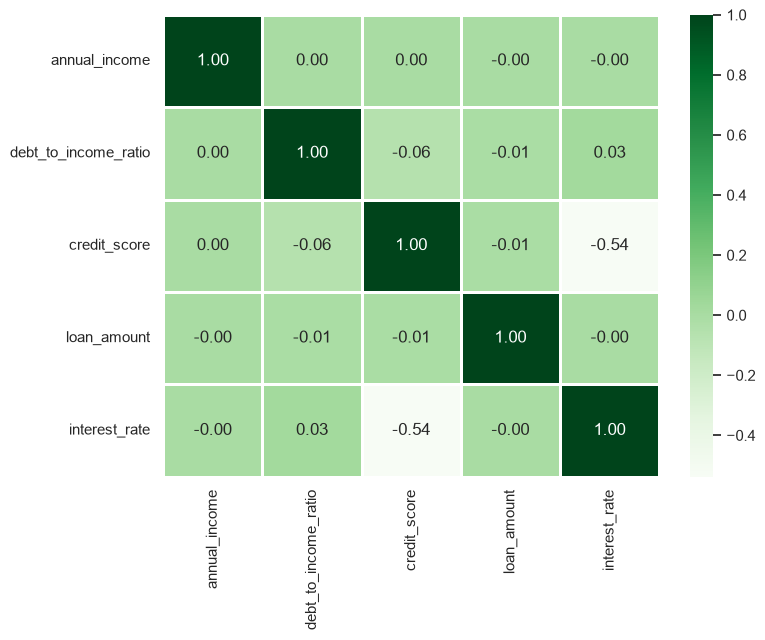

In [97]:
# numerical features correlation
plt.figure(figsize=(8, 6))
correlation_matrix = train[numerical_features ].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', 
            linewidths=1, cmap="Greens")
plt.show()

In [98]:
numerical_features

['annual_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate']


📌 annual_income Summary Statistics:


,Train,Test
Mean,48212.202976,48233.080193
Median,46557.680000,46528.980000
Std,26711.942078,26719.658580


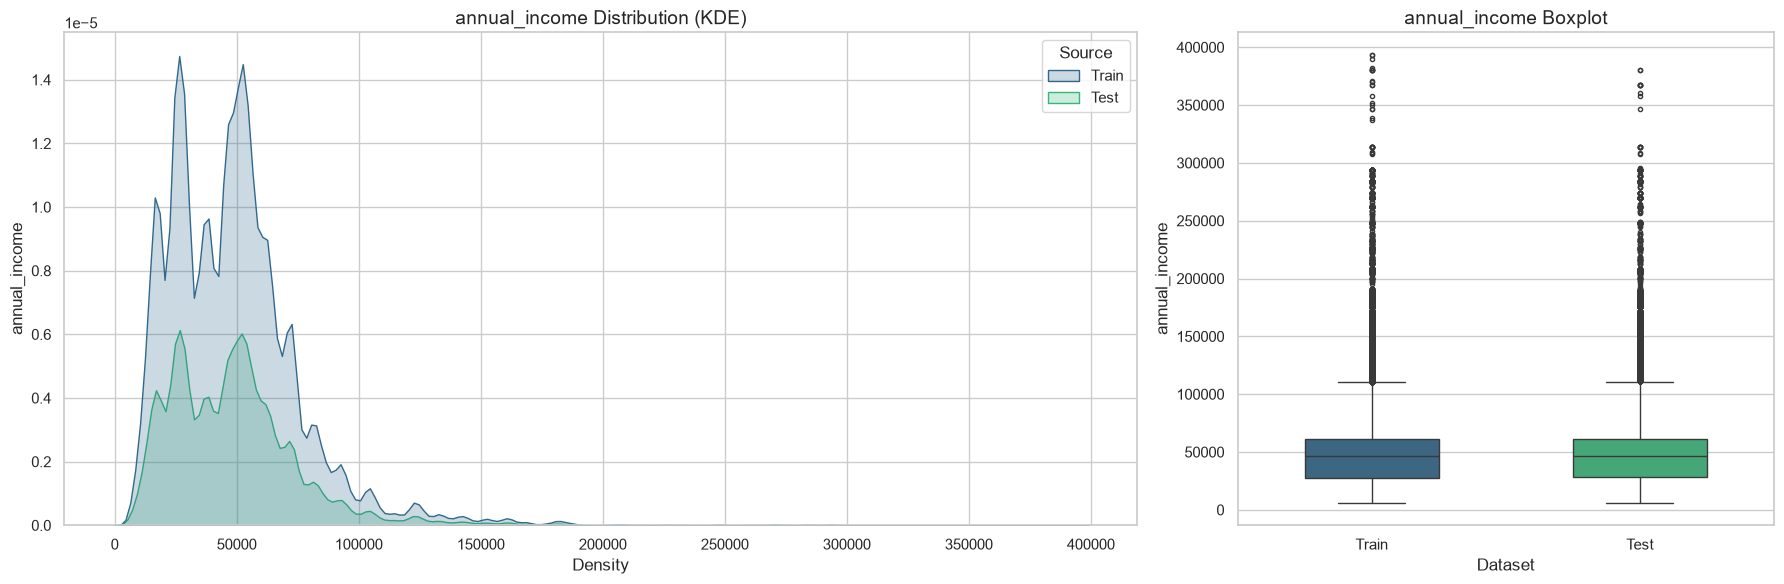


📌 debt_to_income_ratio Summary Statistics:


,Train,Test
Mean,0.120696,0.120583
Median,0.096000,0.096000
Std,0.068573,0.068582


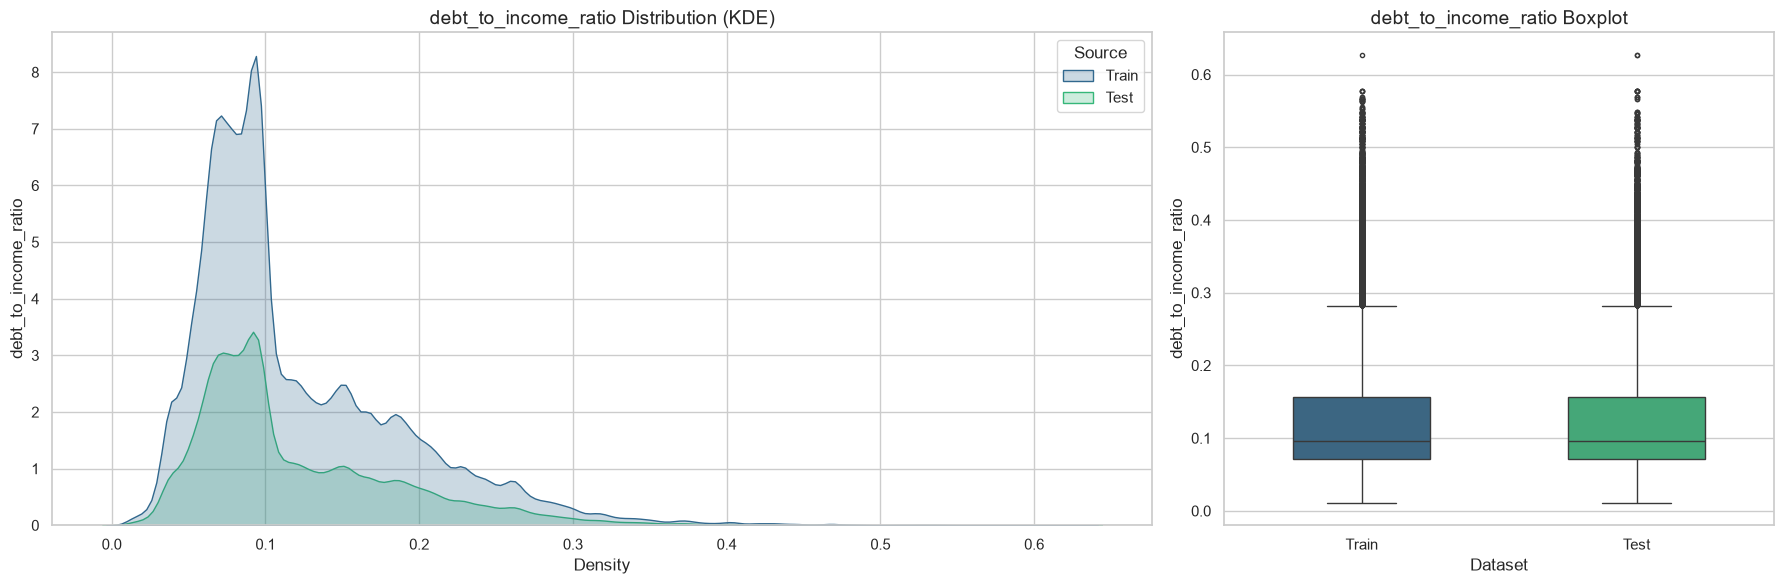


📌 credit_score Summary Statistics:


,Train,Test
Mean,680.916009,681.037691
Median,682.000000,683.000000
Std,55.424956,55.624118


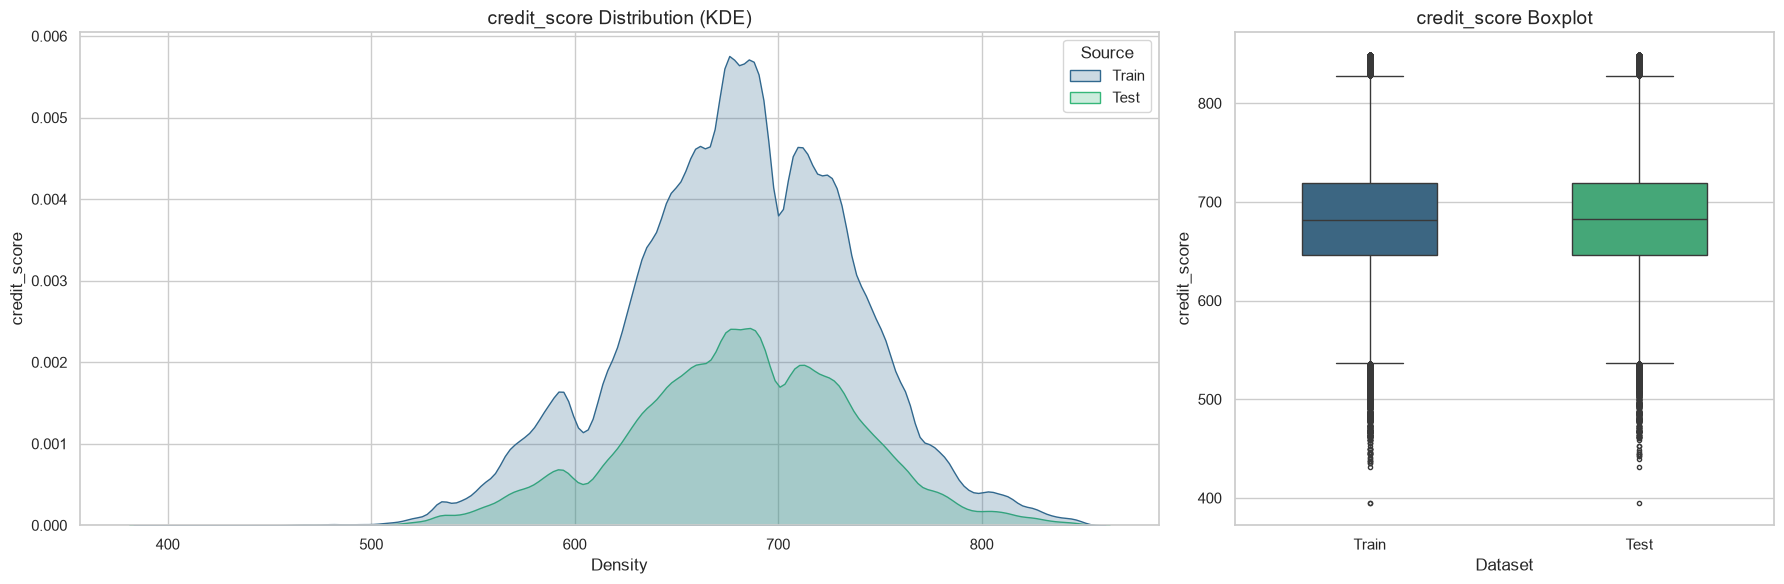


📌 loan_amount Summary Statistics:


,Train,Test
Mean,15020.297629,15016.753484
Median,15000.220000,15000.220000
Std,6926.530568,6922.165182


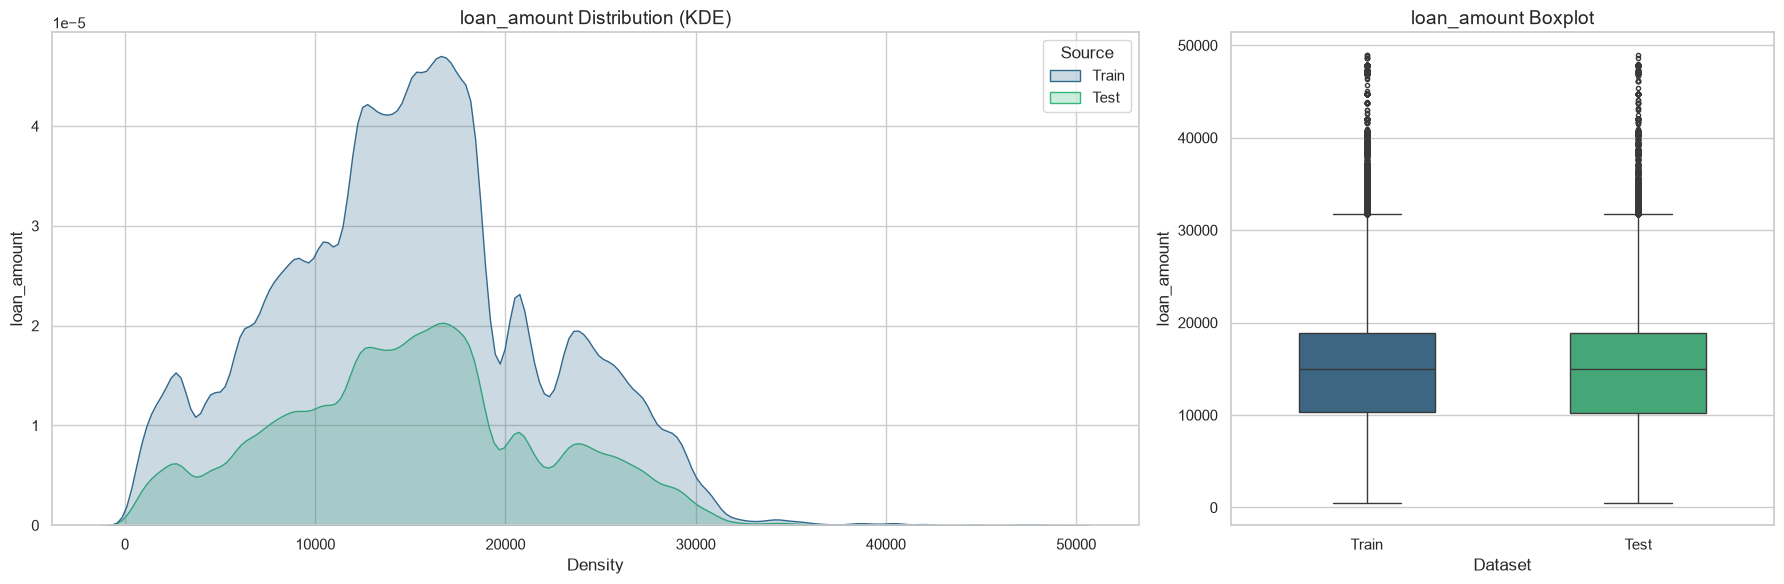


📌 interest_rate Summary Statistics:


,Train,Test
Mean,12.356345,12.352323
Median,12.370000,12.370000
Std,2.008959,2.017602


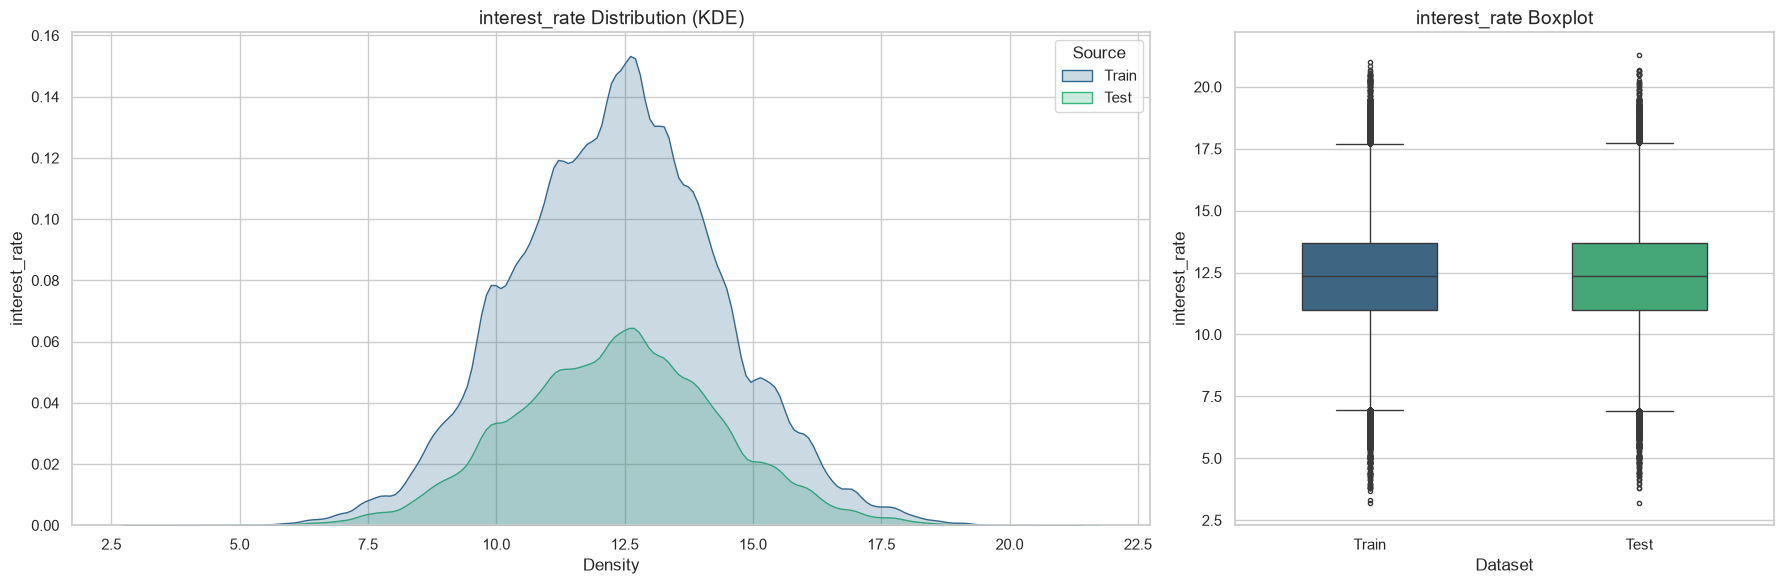

In [99]:
def plot_numerical_distributions(train_df, test_df, numerical_cols):
    """
    Generates KDE and box plots for numerical features, comparing train vs test distributions,
    with summary statistics printed.
    """
    sns.set_style("whitegrid")
    sns.set_context("notebook")
    
    # Combine train and test for plotting
    combined_df = pd.concat([
        train_df[numerical_cols].assign(Source='Train'),
        test_df[numerical_cols].assign(Source='Test')
    ], axis=0, ignore_index=True)

    palette = ['#1f77b4', '#ff7f0e']  # Distinct colors for Train/Test

    for col in numerical_cols:
        # Summary Stats
        print(f"\n📌 {col} Summary Statistics:")
        display(pd.DataFrame({
            'Train': [train_df[col].mean(), train_df[col].median(), train_df[col].std()],
            'Test': [test_df[col].mean(), test_df[col].median(), test_df[col].std()]
        }, index=['Mean', 'Median', 'Std']))

        fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})

        # KDE Plot
        sns.kdeplot(
            data=combined_df, x=col, hue='Source', ax=axes[0], fill=True, palette="viridis"
        )
        axes[0].set_title(f'{col} Distribution (KDE)', fontsize=14)
        axes[0].set_xlabel('Density')
        axes[0].set_ylabel(col)

        # Box Plot
        sns.boxplot(
            data=combined_df, y=col, x='Source', ax=axes[1],
            orient='v', width=0.5, linewidth=1, fliersize=3, palette="viridis"
        )
        axes[1].set_title(f'{col} Boxplot', fontsize=14)
        axes[1].set_xlabel('Dataset')
        axes[1].set_ylabel(col)

        plt.tight_layout()
        plt.show()

# Call numerical distribution function
plot_numerical_distributions(train, test, numerical_features)

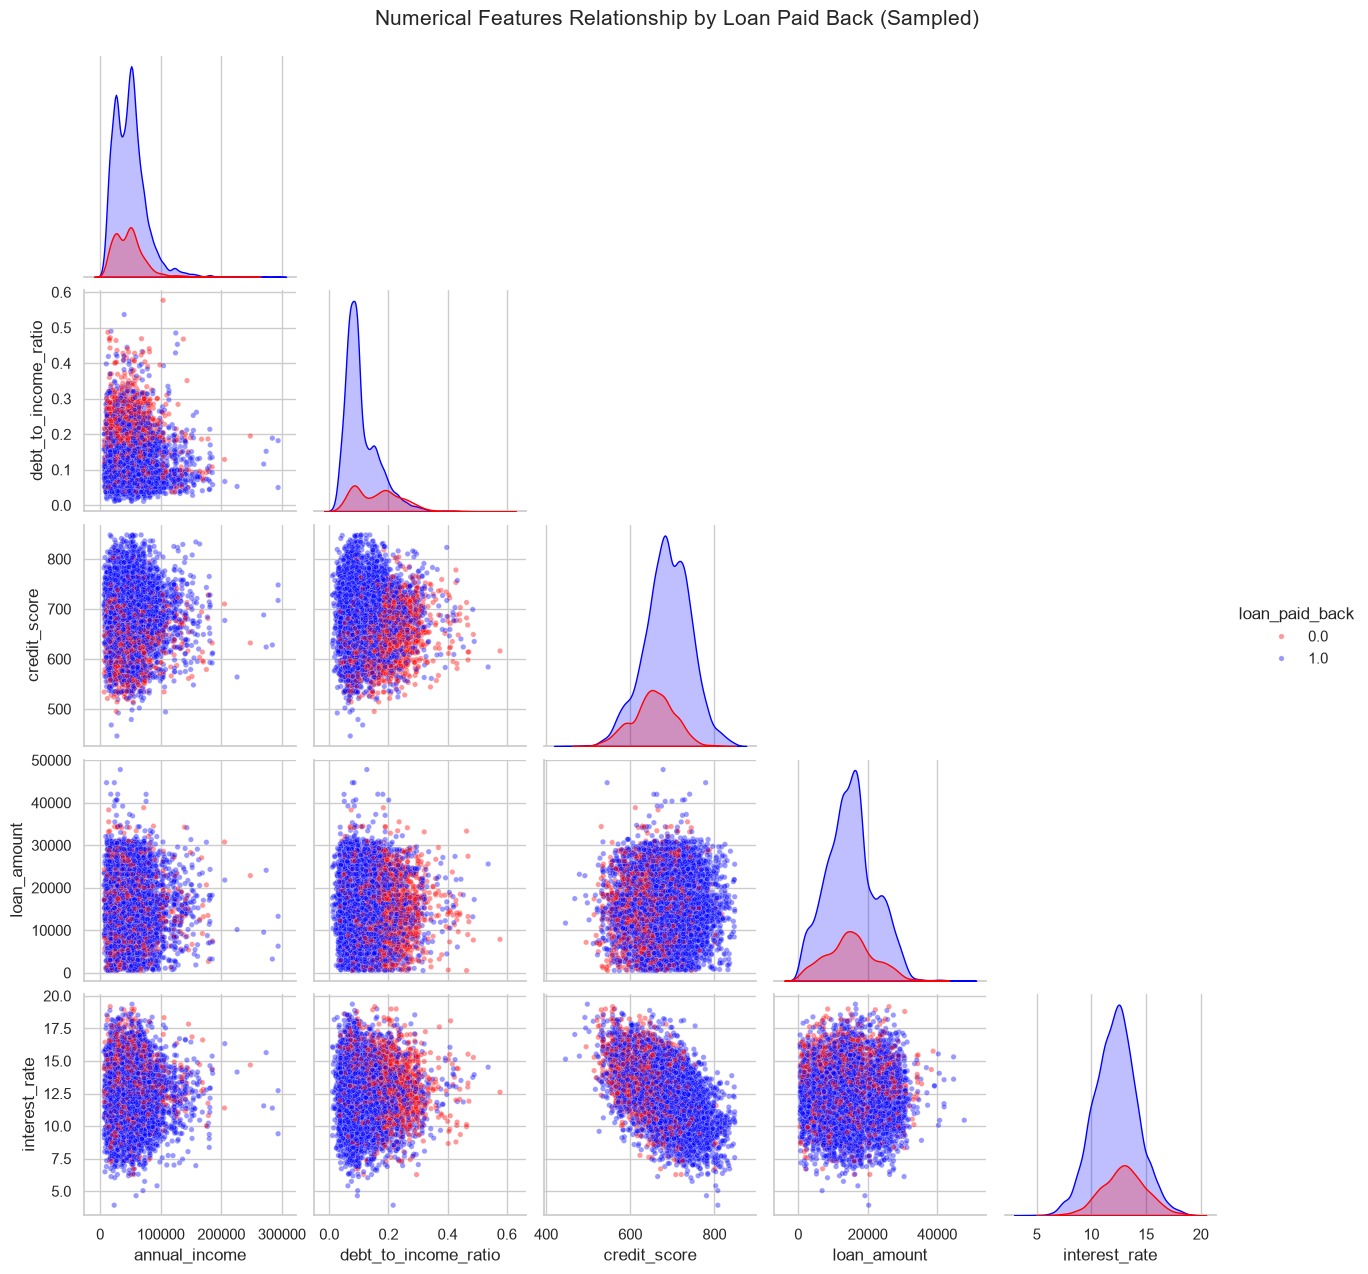

In [100]:
sns.set_theme(style="whitegrid")

sample_size = min(10000, len(train))
df_sample = train[numerical_features + ["loan_paid_back"]].sample(
    n=sample_size, random_state=42
)

g = sns.pairplot(
    df_sample,
    hue="loan_paid_back",
    palette={True: "blue", False: "red"},
    diag_kind="kde",
    corner=True,
    height=2.5,
    plot_kws={"alpha": 0.4, "s": 15},  
    diag_kws={"fill": True},
)

g.fig.suptitle(
    "Numerical Features Relationship by Loan Paid Back (Sampled)",
    y=1.02,
    fontsize=15,
)
plt.show()

## Target Analysis

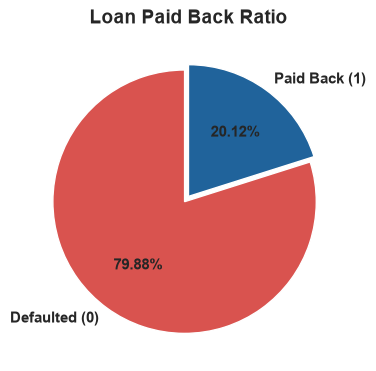

In [101]:
# 1. Count values for the target variable
counts = train["loan_paid_back"].value_counts()

# 2. Define English labels and high-contrast colors
labels = ["Defaulted (0)", "Paid Back (1)"]
colors = ["#D9534F", "#20639B"]  # Muted Red & Navy Blue

# 3. Plot the pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=labels,
    autopct="%.2f%%",  # Displays percentage values
    startangle=90,  # Rotates the start position for better alignment
    colors=colors,
    explode=(0.05, 0),  # Slightly separates the first slice for visual focus
    textprops={"fontsize": 11, "weight": "bold"},
)

plt.title("Loan Paid Back Ratio", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

## Categorical Feature Analysis

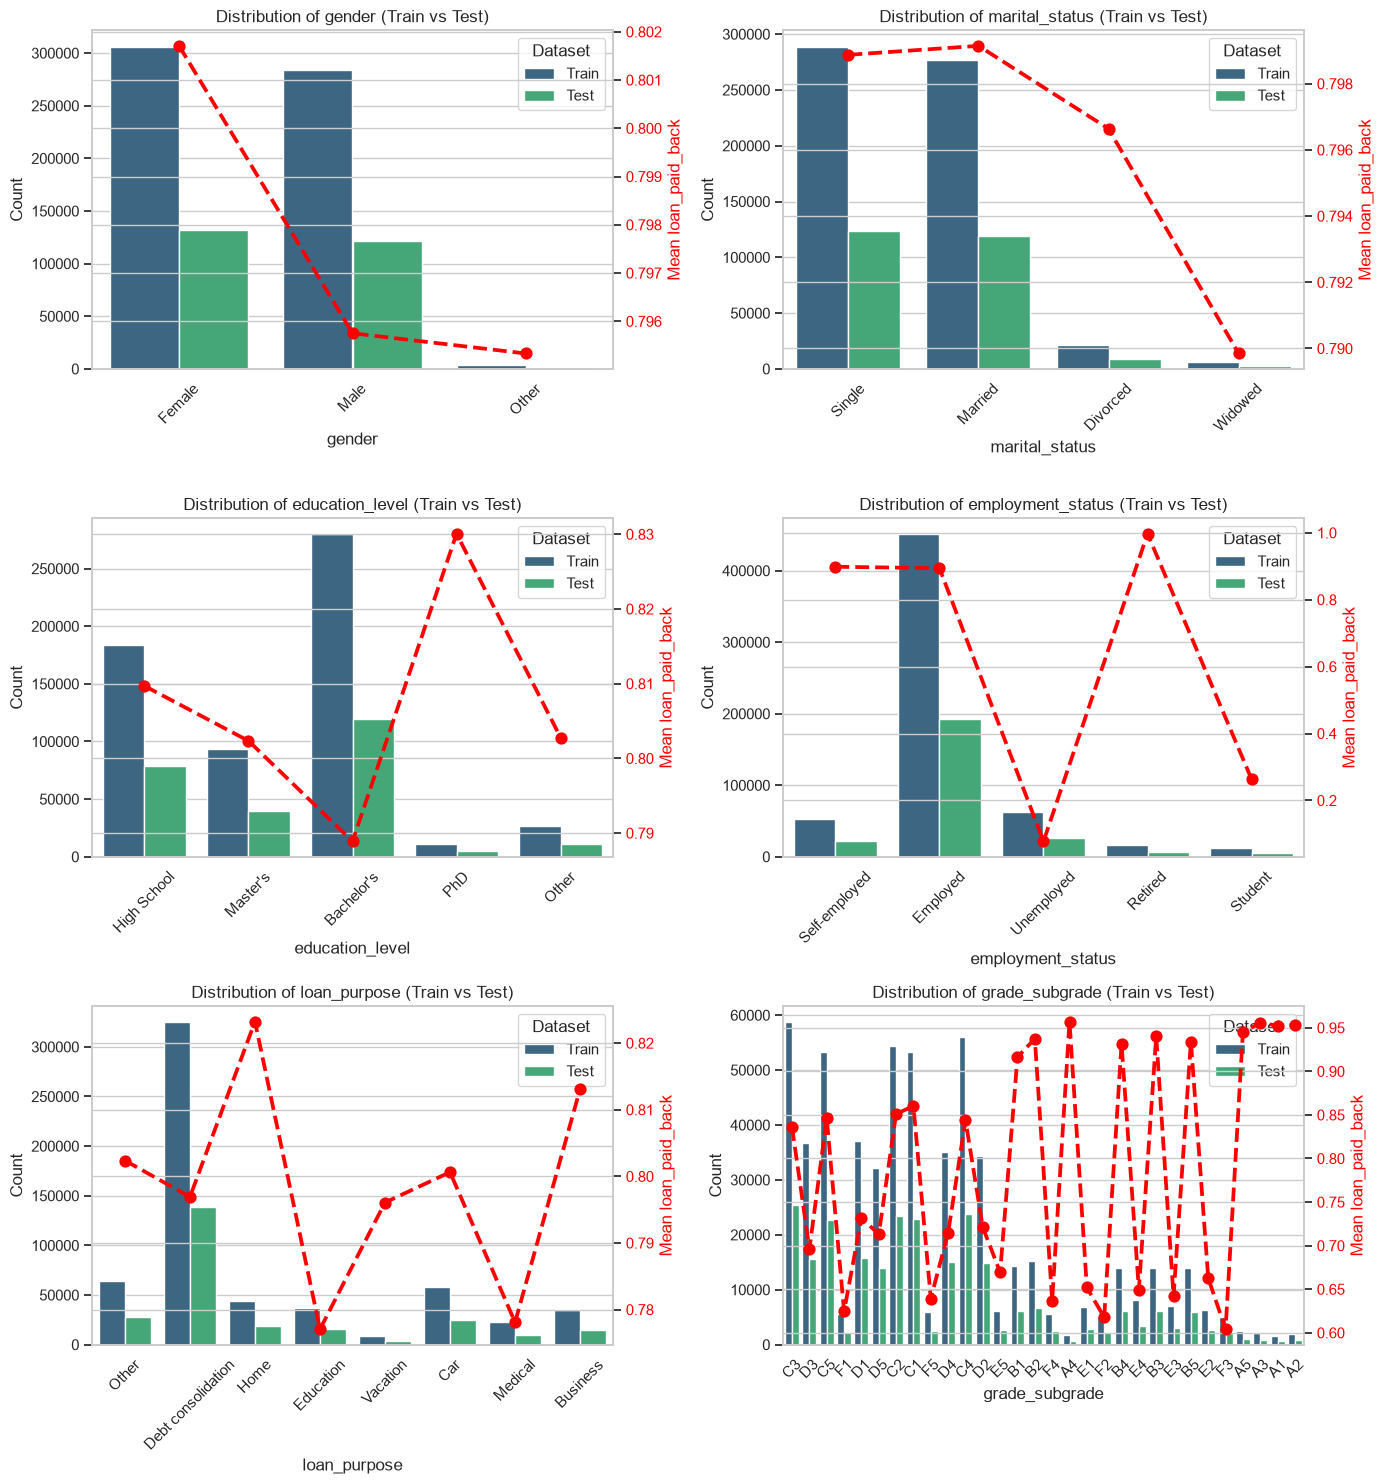

In [102]:
def plot_categorical_distributions(train_df, test_df, categorical_cols, target='loan_paid_back'):
    """
    Generates count plots for each categorical feature (train vs test)
    and bar plots showing mean target per category.
    Uses a denser layout with 2 plots per row.
    """
    if len(categorical_cols) == 0:
        print("No categorical features to plot.")
        return

    palette = ['#1f77b4', '#ff7f0e']  # Train / Test colors
    n_cols = 2
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
    axes = axes.flatten()  # Flatten axes array for easy iteration

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        # Combine train and test for countplots
        combined = pd.concat([
            train_df[[col]].assign(Source='Train'),
            test_df[[col]].assign(Source='Test')
        ], axis=0, ignore_index=True)

        sns.countplot(x=col, hue='Source', data=combined, palette="viridis", ax=ax)
        ax.set_title(f'Distribution of {col} (Train vs Test)', fontsize=12)
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend(title='Dataset')
        ax.tick_params(axis='x', rotation=45)

        # Overlay mean target per category as a line/barplot
        target_means = train_df.groupby(col)[target].mean().sort_values(ascending=False)
        ax2 = ax.twinx()
        sns.pointplot(x=target_means.index, y=target_means.values, ax=ax2, color='red', markers='o', linestyles='--')
        ax2.set_ylabel(f'Mean {target}', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Call the enhanced function
plot_categorical_distributions(train, test, categorical_features, target='loan_paid_back')


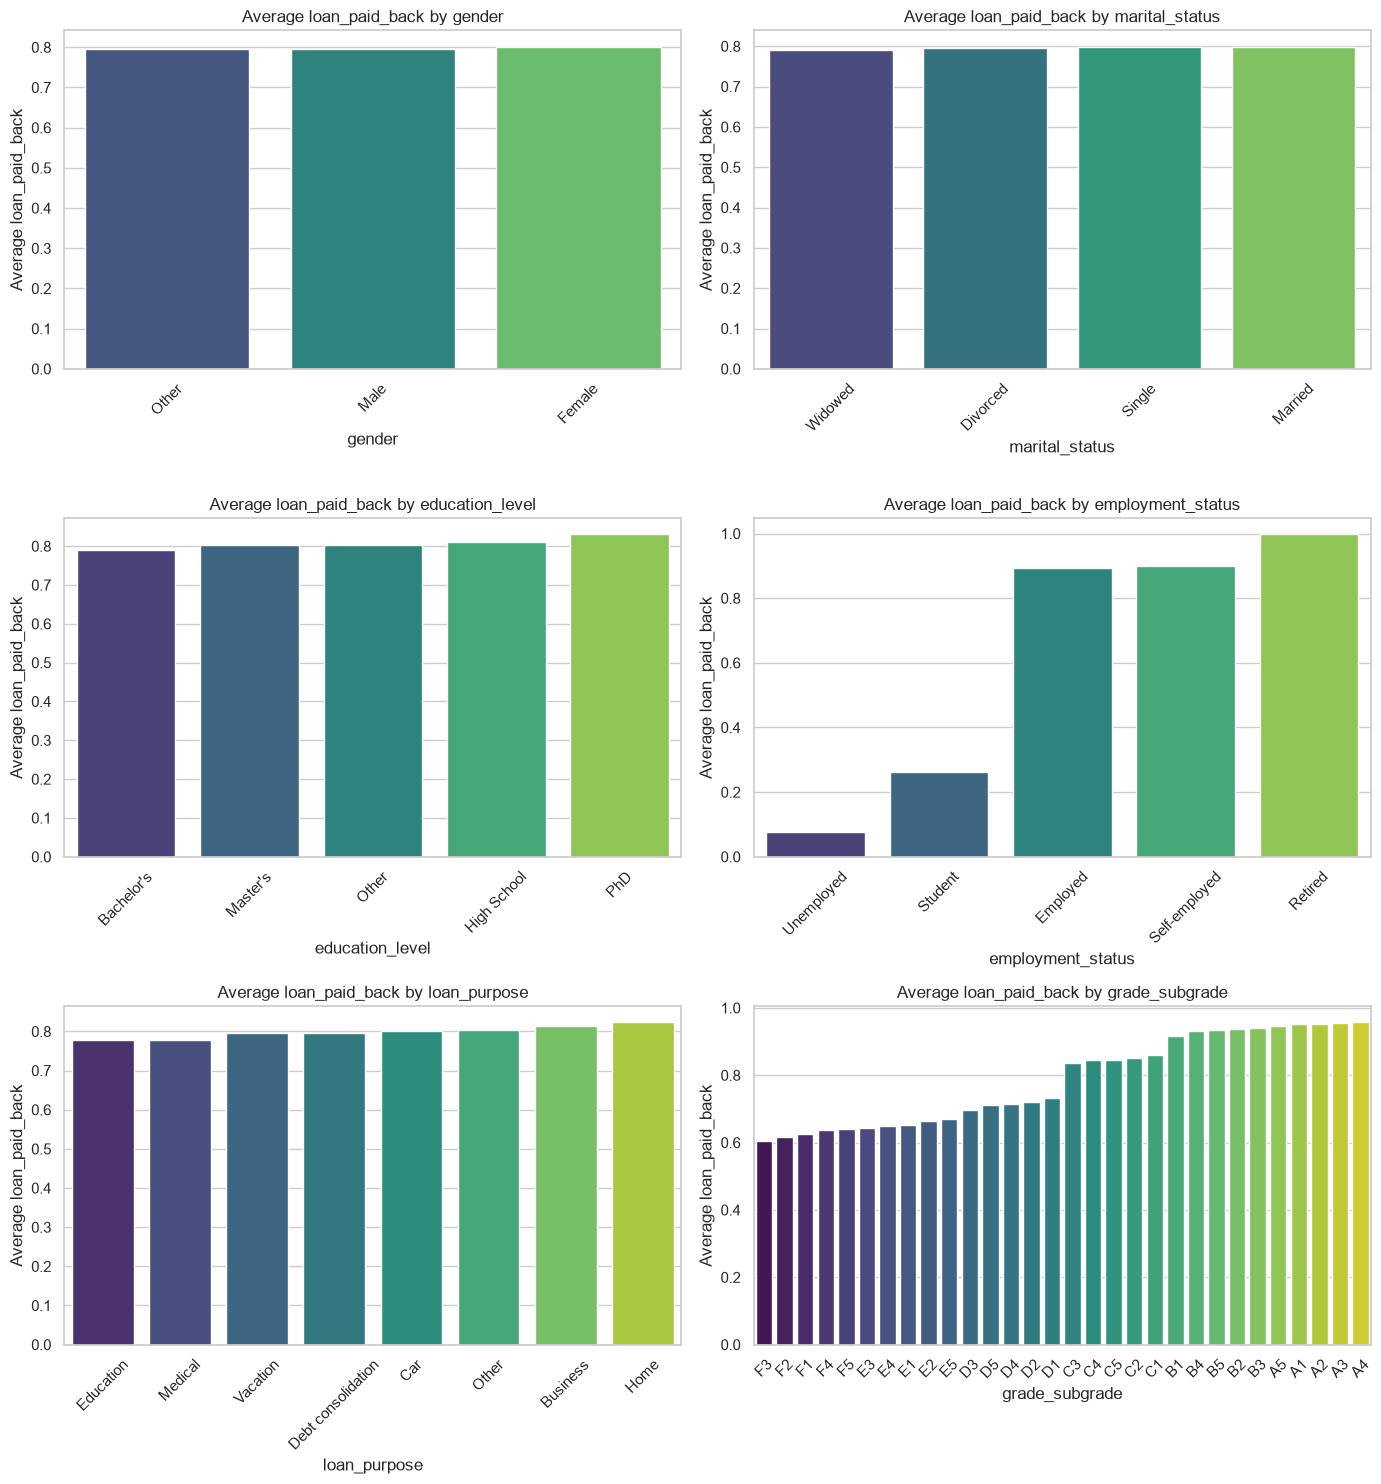

In [103]:
def plot_average_risk_by_category(train_df, categorical_cols, target_col):
    """
    Generates bar plots showing the average target value for each category
    in the specified categorical columns.
    """
    if len(categorical_cols) == 0:
        print("No categorical features to plot.")
        return

    n_cols = 2
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
    axes = axes.flatten() # Flatten the axes array

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        # Calculate average target value per category
        avg_risk = train_df.groupby(col)[target_col].mean().sort_values()

        sns.barplot(x=avg_risk.index, y=avg_risk.values, ax=ax, palette='viridis')

        ax.set_title(f'Average {target_col} by {col}', fontsize=12)
        ax.set_xlabel(col)
        ax.set_ylabel(f'Average {target_col}')
        ax.tick_params(axis='x', rotation=45)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Call the function
plot_average_risk_by_category(train, categorical_features, 'loan_paid_back')